In [888]:
import sys
from pathlib import Path
sys.path.append('../')

from matching_clustering.utils import LapOT
from matching_clustering.helpers_3D import create_3D_clouds, plot_3D_point_clouds_side_by_side, plot_point_clouds_only, spectral_cluster_labels
from matching_clustering.precompute_helpers import cost_matrix_c, build_cluster_matrix
from __future__ import annotations
import numpy as np
from sklearn.cluster import SpectralClustering
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csgraph
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans


# $\text{Refined Simultaneous Clustering}$ ($\text{RSC}$) 
### Load and plot point clouds $X$ and $Y$ from the CAPOD dataset

In [1752]:
path_X = "../Data/CAPOD/class1/m1.obj"
path_Y = "../Data/CAPOD/class1/m2.obj"
X, Y = create_3D_clouds(path_X, path_Y)


# Uncomment and run the following line to visualize the point clouds in an interactive 3D plotly figure
plot_3D_point_clouds_side_by_side(X, Y)

/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m1.obj: Load time: 0.010485172271728516
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m1.obj: Load time: 0.010485172271728516
/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m2.obj: Load time: 0.010380029678344727
INFO:pywavefront:/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/Data/CAPOD/class1/m2.obj: Load time: 0.010380029678344727


### For reference, independently apply Spectral Clustering on clouds X and Y and visualize the results

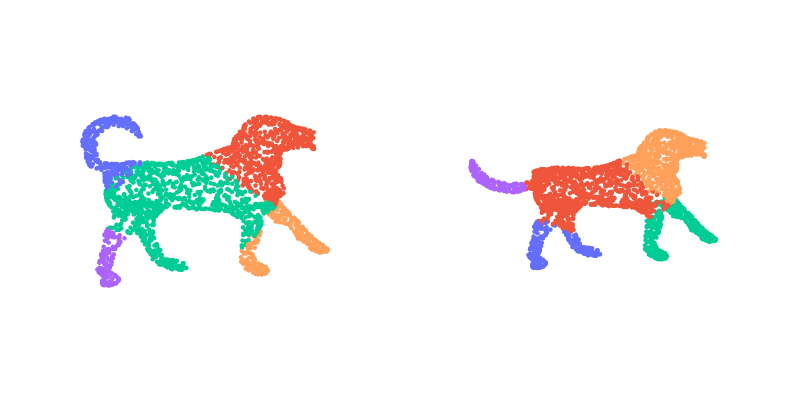

In [ ]:
sc_X = SpectralClustering(n_clusters=5, affinity='rbf', gamma=1/(0.3**2*2), random_state=42)
labels_X = sc_X.fit_predict(X)

sc_Y = SpectralClustering(n_clusters=5, affinity='rbf', gamma=1/(0.3**2*2), random_state=42)
labels_Y = sc_Y.fit_predict(Y)


base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "Dogs" /  "dogs_independent_spectral_clustering.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_point_clouds_only(
    X,
    Y,
    labels_X,
    labels_Y,
    elev=10,
    azim=180,
    point_size=5,
    save_path=None,  # set to output_path to save the figure
    plot_clouds_only=False
)

## Continue with $\text{RSC}$ applied on clouds $X$ and $Y$:
### Step 1: Pre-compute  $L_X, L_Y$ and $C$ matrices and the marginal distributions $w$ and $q$.


### Note: For the derivation of  $L_X$ and $L_Y$ we use the same $\sigma$ as for the independent spectral clustering in the cell above.


#### In adition, since clouds $X$ and $Y$ are different embeddings of the same object, for the computation of the marginals $w$ and $q$ we adjust $\sigma$ so it will capture local geometry of both clouds. We know that tunning $\sigma$ to be small enough will make the histograms of $w$ and $q$ almost identical (Gaussian similarity still produce connected graphs and hence, the effect of the different embeddings although small is still present even for small sigmas). Here we also note that sigma should not be too small, since we want $a$ and $b$ capture the shared local geometry of both clouds on one hand but also be of relatively low resolution. Notice that using independent spectral clustering using this value $\sigma$ does not produce a consistent result across clouds.

In [1740]:
import logging
logging.basicConfig(level=logging.INFO, force=True)


# Calculate the Gaussian (RBF) kernel matrices for X and Y
W_X = rbf_kernel(X, gamma=1/(0.3**2*2))
W_Y = rbf_kernel(Y, gamma=1/(0.3**2*2))



# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


# can we do nearest neighbor graph
# adjust sigma values for smaller significatnce neighborhoodd

W_X_match = rbf_kernel(X, gamma=1/(0.2**2*2))
# np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(0.2**2*2))
# np.fill_diagonal(W_Y_match, 0)

L_X_match = csgraph.laplacian(W_X_match, normed=False)
L_Y_match = csgraph.laplacian(W_Y_match, normed=False)

# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()

### Calculate $C$

In [ ]:
C_RSC = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 4184 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 50152 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 139752 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done 254952 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done 395752 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done 562152 tasks      | elapsed:   49.0s
[Parallel(n_jobs=-1)]: Done 754152 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 971752 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1214952 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1483752 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1778152 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2098152 tasks      | elapsed:  2.9min
[Parallel

### Load pre-computed  $C$

In [ ]:
# uncomment the following line to load the precomputed cost matrix C_RSC from a file
# Specify the path to the precomputed cost matrix C_RSC

# C_RSC = np.load(base_dir / "Precomputed" / "C_RSC.npy")

### Step 2: Solve $\text{LapOT}$ and refine $L_X, L_Y$ based on the switch matrices $ \pi_{switch}^X, \pi_{switch}^Y$

#### Notice:

Beyond the model's hyper parameters $\lambda,\lambda_x,~\text{and}~\lambda_y$, we also have a degree of freedom in deciding the number of clusters $k$ to which we partition the rows and columns of the optimal coupling $\pi^\star$ solving $\text{LapOT}$.

The number $k$ will partition the clouds $X$ and $Y$ into sets that share similar matches with the oposite cloud. We expect that the result will reflect the degree heirarchy present in the data (Which is dependant on sigma that was chosen). Obviously the choise of $k$ is data dependant. In reality we see that a good practice is to set k=2 or k=3 which gives the data a rough initial partition on top of which we further aplly spectral clustering.  



In [1741]:
epsilon = 1e-6
l = 0.1   # entropic regularization parameter
l_x = 10.0  # Laplacian regularization parameter for X
l_y = 10.0 # Laplacian regularization parameter for Y

# Solve the LapOT problem using the fixed-point iteration method
prob = LapOT(L_X_match, L_Y_match, C_RSC, l, l_x, l_y, w=a, v=b)
pi_fp = prob.solve(method='fp', max_iter=10000, tau_scale=1, verbose=True)



Initialization: objective = -1.4912439811795197
Implement fixed point algorithm
max of entropy term :-1.6093292514629316 
 max of main term: 0.09146422184747674
Iteration 1: objective = -1.5178650296154548, objective relative change = -0.017851571420847423, pi change (L1) = 0.5194692467929868
max of entropy term :-1.6097175764042673 
 max of main term: 0.09184843639276594
Iteration 2: objective = -1.5178691400115014, objective relative change = -2.708011559949367e-06, pi change (L1) = 0.0072730834250065695
max of entropy term :-1.6097075478139518 
 max of main term: 0.09183839841416115
Iteration 3: objective = -1.5178691493997907, objective relative change = -6.185176975826904e-09, pi change (L1) = 0.00026953667655008756
max of entropy term :-1.60970799073375 
 max of main term: 0.09183884128237232
Iteration 4: objective = -1.5178691494513776, objective relative change = -3.39864321959615e-11, pi change (L1) = 1.4813260925503472e-05
max of entropy term :-1.6097079645344394 
 max of mai

### Load pre-computed $\pi^\star$ 

In [ ]:
# uncomment the following line to load the precomputed cost matrix pi_fp from a file
# Specify the path to the precomputed cost matrix pi_fp

# pi_fp = np.load(base_dir / "Precomputed" / "pi_fp.npy")

### Derive the switch matrices $\pi^X_{switch}$ and $\pi^Y_{switch}$ and update $K_X \longrightarrow \pi^X_{switch} \odot K_X,~~ K_Y \longrightarrow \pi^Y_{switch} \odot K_Y$ 

In [ ]:
# save the cost matrix C_RSC to a file for later use

out_dir = base_dir / "Precomputed" / "Dogs_RSC"
out_dir.mkdir(parents=True, exist_ok=True)

# np.save(out_dir / "pi_fp_Dogs_class9_m97_m98.npy", pi_fp)
# np.save(out_dir / "C_Dogs_class9_m97_m98.npy", C_RSC)
# np.save(out_dir / "L_X_Dogs_class9_m97_m98.npy", L_X)
# np.save(out_dir / "L_Y_Dogs_class9_m97_m98.npy", L_Y)

In [1742]:
# derive the switch matrices 
pi_switch_x = build_cluster_matrix(pi_fp, k=2)
pi_switch_y = build_cluster_matrix(pi_fp.T, k=2)

# refine the similarity matrices
new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

### Apply spectral clustering based on the refined matrices $K_X$ and $K_Y$

In [1743]:
# perform spectral clustering on the refined similarity matrices
SC_X = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_X = SC_X.fit_predict(new_similarity_x)

SC_Y = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="cluster_qr", # possible options: "cluster_qr", "kmeans", "discretize"
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_Y = SC_Y.fit_predict(new_similarity_y)


### Visualize  the results of $\text{RSC}$ applied on clouds $X$ and $Y$

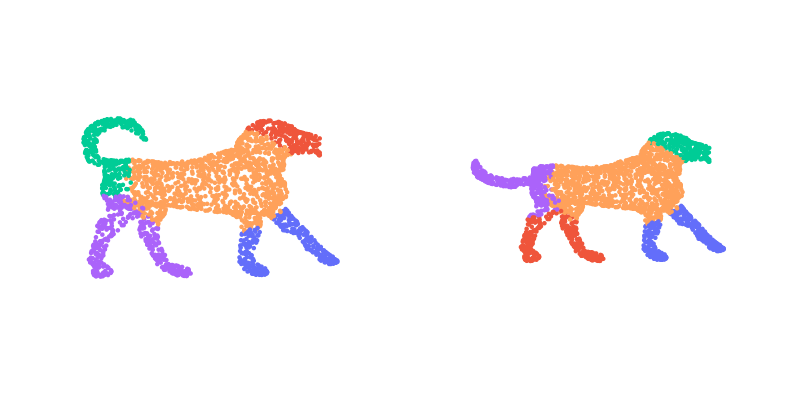

In [ ]:
# Save plot to the folder "Figures" in the current working directory
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "Dogs" /  "RSC_Dogs_class9_m97_m98.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_point_clouds_only(
    X,
    Y,
    labels_refined_X,
    labels_refined_Y,
    elev=0,
    azim=190,
    point_size=5,
    save_path=None # set to output_path to save the figure
)

### Visualize the partition of $X$ and $Y$ induced by $\pi^X_{switch}$ and $\pi^Y_{switch}$

In [1748]:
# Perform KMeans clustering on pi_fp and its transpose to get the switch labels for X and Y
k = 2  # number of clusters for the switch matrix
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
pi_switch_x_labels= kmeans.fit_predict(pi_fp)
pi_switch_y_labels = kmeans.fit_predict(pi_fp.T)

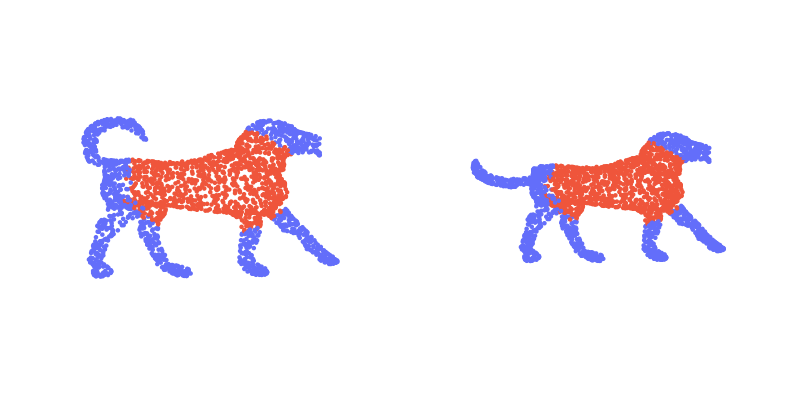

In [ ]:
# Save plot to the folder "Figures" in the current working directory
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "Dogs" /  "Dogs_according_to_switch_matrices.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_point_clouds_only(
    X,
    Y,
    pi_switch_x_labels,
    pi_switch_y_labels,
    elev=0,
    azim=190,
    point_size=5,
    save_path=None # set to output_path to save the figure
)

# Alignment problem experiment:
### <u>Problem setup </u>:

 Given two 3D point clouds $X$ and $Y$ where $Y = RX + \sigma N$ for an unknown rotation $R \in SO(3)$ and additive gaussian noise $N \sim \mathcal{N}(0,1)$ with variance $\sigma$, our goal is estimating the unknown underlying rotation $R$.

 ### <u>Experiment description</u>:
 We compare SOTA ICP method for shape matching, global unconstrained Optimal Transport (OT) matching approach and our method, all with repsect to the relative error $\|R - R_{est}\|_2$, between the estimate rotation and the ground truth for varying values of $\sigma$.

### <u>The steps of our method </u>:
#### Step 1: Apply $\text{RSC}$ on $X$ and $Y$
#### Step 2: Match between the k centroids of the k clusters of $X$ and $Y$ obtained by the $\text{RSC}$
#### Step 3: Simultaneously solve k smaller unconstrained OT matchings between every two matches clusters of $X$ and $Y$
#### Step 4: Concatinate the correspondence between every pair of clusters of $X$ and $Y$ into a global, block structured correspondence between $X$ and $Y$.

## Set cloud $Y$ to be rotated version of cloud  $X$ to which we add Gaussian noise


In [1267]:
%load_ext autoreload
%autoreload 2

def make_rot_xy(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0.0],
                     [s,  c, 0.0],
                     [0.0, 0.0, 1.0]])

def rotate_and_noisify(X, angle=np.pi - 2, noise_std=0.009, seed=None):
    """
    X: np.ndarray of shape (N, 3)
    angle: rotation (radians) in the x-y plane
    noise_std: stddev of isotropic Gaussian noise added to each coord
    seed: optional int for reproducibility
    """
    R = make_rot_xy(angle)
    Y = X @ R.T
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
    Y_noisy = Y + rng.normal(0.0, noise_std, size=Y.shape)
    noise = Y_noisy - Y

    signal_power = np.mean(np.sum(Y**2, axis=1))
    noise_power  = np.mean(np.sum(noise**2, axis=1))

    snr_db = 10 * np.log10(signal_power / noise_power)

    return Y_noisy, snr_db

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Visualize both clouds $X$ and $Y$ (plotting $Y$ without the rotation, so it will be seen from the same angle as $X$)

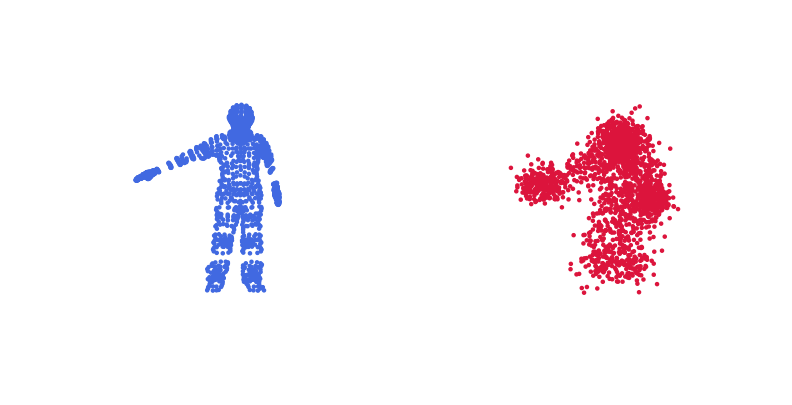

In [1796]:
Y_for_plot, _ = rotate_and_noisify(X, angle=0, noise_std=0.1, seed=42) # Just for purposes of  viewing X and Y from the same angle

Y, _ = rotate_and_noisify(X, angle=np.pi/2, noise_std=0.1, seed=42)  
# plot_3D_point_clouds_side_by_side(X, Y, title="Rotated + Noisy Y vs Original X")

n, m = X.shape[0], Y.shape[0]

labels__X, labels__Y = np.zeros(n), np.zeros(m)

base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "Alignment" /"Alignment_data_1_noise.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plot_point_clouds_only(
    X,
    Y_for_plot,
    labels__X,
    labels__Y,
    elev=15,
    azim=270,
    point_size=5,
    save_path=None, # set to output_path to save the figure
    plot_clouds_only=True
)


### Pre-compute $C, L_X, L_Y$ and the marginals $a$ and $b$

In [1797]:
# Calculate the Gaussian (RBF) kernel matrices for X and Y
W_X = rbf_kernel(X, gamma=1/(0.25*2))
W_Y = rbf_kernel(Y, gamma=1/(0.25*2))


# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


# can we do nearest neighbor graph
# adjust sigma values for smaller significatnce neighborhoodd

W_X_match = rbf_kernel(X, gamma=1/(0.077**2*2))
np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(0.077**2*2))
np.fill_diagonal(W_Y_match, 0)

# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()


In [ ]:

C = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

# out_dir = base_dir / "Precomputed" / "Alignment"
# out_dir.mkdir(parents=True, exist_ok=True)

# np.save(out_dir / "C_Alignment_1_noise.npy", C)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 66024 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 155624 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 270824 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 411624 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done 578024 tasks      | elapsed:   41.5s
[Parallel(n_jobs=-1)]: Done 770024 tasks      | elapsed:   55.4s
[Parallel(n_jobs=-1)]: Done 987624 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1230824 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1499624 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1794024 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2114024 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 2459624 tasks      | elapsed:  2.9min
[Parallel(n_jo

### Solve $\text{LapOT}$ and refine $L_X, L_Y$ based on the switch matrices $\pi_{switch}^X$ and $\pi_{switch}^Y$

In [1799]:
epsilon = 1e-6
l = 0.5  # lambda
l_x = 10
l_y = 10

# optimize our objective
prob = LapOT(L_X, L_Y, C, l, l_x, l_y, w=a, v=b)
pi_fp = prob.solve(method='fp', verbose=True)


# derive the switch matrices
pi_switch_x = build_cluster_matrix(pi_fp, k=2)
pi_switch_y = build_cluster_matrix(pi_fp.T, k=2)

# refine the similarity matrices
new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

SC_X = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_X = SC_X.fit_predict(new_similarity_x)

SC_Y = SpectralClustering(
    n_clusters=5,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=42,
    n_init=10,
    eigen_solver=None,  # let sklearn choose
)
labels_refined_Y = SC_Y.fit_predict(new_similarity_y)

Initialization: objective = -7.596741619130687
Implement fixed point algorithm
max of entropy term :-7.80250470367147 
 max of main term: 0.19931578662071298
Iteration 1: objective = -7.603188917050757, objective relative change = -0.0008486925373155263, pi change (L1) = 0.12260576913311722
max of entropy term :-7.802745751792852 
 max of main term: 0.19955217296407773
Iteration 2: objective = -7.603193578828774, objective relative change = -6.131345765315857e-07, pi change (L1) = 0.003350488148469327
max of entropy term :-7.802736267164791 
 max of main term: 0.19954267033715778
Iteration 3: objective = -7.603193596827634, objective relative change = -2.3672762116694072e-09, pi change (L1) = 0.00018152347882906538
max of entropy term :-7.802736803903006 
 max of main term: 0.19954320695304031
Iteration 4: objective = -7.603193596949965, objective relative change = -1.6089486177439844e-11, pi change (L1) = 1.3245309692740251e-05
max of entropy term :-7.802736767168022 
 max of main ter

### Visualize results of $\text{RSC}$ applied on clouds $X$ and $Y$

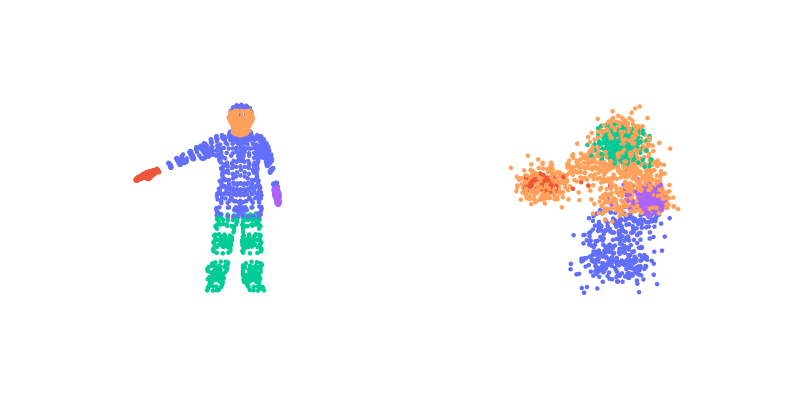

In [ ]:
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" /"Alignment" /  "RSC_alignment_1_noise.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plot_point_clouds_only(
    X,
    Y_for_plot,
    labels_refined_X,
    labels_refined_Y,
    elev=15,
    azim=270,
    point_size=5,
    save_path=None, # set to output_path to save the figure
)

### Partition $X$ and $Y$ into their clusters based on the labels we got from the $\text{RSC}$ step above
#### Compute centroids of each cluster (based on cluster median or mean)


In [1273]:
clusters_X = [X[labels_refined_X == i] for i in range(5)]
clusters_Y = [Y[labels_refined_Y == i] for i in range(5)]

centroids_X = [np.median(cluster, axis=0) for cluster in clusters_X] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
centroids_Y = [np.median(cluster, axis=0) for cluster in clusters_Y] # We use the median here to be more robust to outliers in the point clouds, but the mean could also be used
a_clusters =np.hstack([a[labels_refined_X == i].sum() / np.sum(a) for i in range(5)])
b_clusters = np.hstack([b[labels_refined_Y == i].sum() / np.sum(b) for i in range(5)])


# Calculate the full distance matrix
pairwise_distances_centroids_X = pairwise_distances(np.vstack(centroids_X), metric='euclidean')
pairwise_distances_centroids_Y = pairwise_distances(np.vstack(centroids_Y), metric='euclidean')


C_centroids = cost_matrix_c(pairwise_distances_centroids_X, pairwise_distances_centroids_Y, a=a_clusters, b=b_clusters)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    2.9s finished


### Match between cluster centroids of $X$ and $Y$

In [1274]:
import ot


N = C_centroids.shape[0]

a_unif = np.ones(N) / N
b_unif = np.ones(N) / N

# Exact OT plan
gamma = ot.emd(a_unif, b_unif, C_centroids)
j_max = np.argmax(gamma, axis=1)


print("Cluster correspondences:",'[0 1 2 3 4] of X to -->', j_max, 'of Y')

Cluster correspondences: [0 1 2 3 4] of X to --> [1 3 2 4 0] of Y


## Calculate 5 simultaneous matches (Cluster to cluster)
### Step 1: Pre-compute cost matrices $C_1, \dots, C_5$

In [1275]:
pairwise_X = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_X]
pairwise_Y = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_Y]
a_clusters = [a[labels_refined_X == i] / np.sum(a[labels_refined_X == i]) for i in range(5)]
b_clusters = [b[labels_refined_Y == i] / np.sum(b[labels_refined_Y == i]) for i in range(5)]
C_clusters = [cost_matrix_c(pairwise_X[i], pairwise_Y[j_max[i]], a=a_clusters[i], b=b_clusters[j_max[i]]) for i in range(5)]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 529384 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 600760 out of 600760 | elapsed:   20.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 37204 out of 37204 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 111707 tasks      |

### Step 2: Match and plot the OT plans

In [1276]:
a_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_X]
b_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_Y]

gamma_clusters = [ot.emd(a_unifs[i], b_unifs[j_max[i]], C_clusters[i]) for i in range(5)]

### $\bullet$ Set the correspondence between every point $x_i \in X$ to be the maximal entry of it's fuzzy match with $Y$
### $\bullet$ Calculate the global OT plan between $X$ and $Y$ given the pre-computed cost matrix $C$

In [1277]:
J_max = [np.argmax(gamma_clusters[i], axis=1) for i in range(5)]
Y_new = [clusters_Y[j_max[i]][J_max[i]] for i in range(5)]

# Arrange the the data according to the new correspondences
Y__new = np.vstack(Y_new)
X__new = np.vstack(clusters_X)


# Calculate global correspondence using the original cost matrix C and unconstrained OT
global_a_unif, global_b_unif = np.ones(X.shape[0]) / X.shape[0], np.ones(Y.shape[0]) / Y.shape[0]
PI = ot.emd(global_a_unif, global_b_unif, C)
arg_max_PI = np.argmax(PI, axis=1)
reordered_Y = Y[arg_max_PI]

### Estimate the underlying rotation using Procrustes algorithm

In [1278]:
def estimate_rotation(cloud_1, cloud_2):

  # X, Y: (n,3) arrays with corresponding rows
  x_bar = cloud_1.mean(axis=0)
  y_bar = cloud_2.mean(axis=0)

  Xc = cloud_1 - x_bar
  Yc = cloud_2 - y_bar

  H = Xc.T @ Yc
  U, S, Vt = np.linalg.svd(H)
  R = Vt.T @ np.diag([1, 1, np.sign(np.linalg.det(Vt.T @ U.T))]) @ U.T
  t = y_bar - R @ x_bar  # optional
  return R, t

R_real = make_rot_xy(np.pi/2)
R, t = estimate_rotation(X__new, Y__new)
R_global, t_global = estimate_rotation(X, reordered_Y)
print('Relative error using local registration with our method:', np.linalg.norm(R - R_real))
print('Relative error using global registration:', np.linalg.norm(R_global - R_real))

Relative error using local registration with our method: 0.02397104641720916
Relative error using global registration: 0.024442121239942338


# SOTA ICP

In [372]:
import numpy as np
import open3d as o3d


def numpy_to_pcd(points: np.ndarray) -> o3d.geometry.PointCloud:
    """Convert (N, 3) numpy array to an Open3D point cloud."""
    points = np.asarray(points, dtype=np.float64)
    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"Expected shape (N, 3), got {points.shape}")
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    return pcd


def estimate_voxel_size(X: np.ndarray, Y: np.ndarray, divisor: float = 30.0) -> float:
    """
    Heuristic voxel size from the combined bounding box diagonal.
    Increase divisor for denser clouds; decrease for sparser clouds.
    """
    pts = np.vstack([X, Y])
    bbox_min = pts.min(axis=0)
    bbox_max = pts.max(axis=0)
    diag = np.linalg.norm(bbox_max - bbox_min)
    voxel_size = diag / divisor
    return max(voxel_size, 1e-6)


def preprocess_point_cloud(pcd: o3d.geometry.PointCloud, voxel_size: float):
    """
    Downsample, estimate normals, and compute FPFH features.
    """
    pcd_down = pcd.voxel_down_sample(voxel_size)

    # Normals are needed for point-to-plane ICP, GICP, and FPFH.
    normal_radius = voxel_size * 2.0
    feature_radius = voxel_size * 5.0

    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=normal_radius, max_nn=30)
    )

    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down,
        o3d.geometry.KDTreeSearchParamHybrid(radius=feature_radius, max_nn=100),
    )
    return pcd_down, fpfh


def global_registration_ransac(
    source_down: o3d.geometry.PointCloud,
    target_down: o3d.geometry.PointCloud,
    source_fpfh,
    target_fpfh,
    voxel_size: float,
):
    """
    Correspondence-free initialization via FPFH + RANSAC.
    """
    distance_threshold = voxel_size * 1.5

    result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source_down,
        target_down,
        source_fpfh,
        target_fpfh,
        mutual_filter=True,
        max_correspondence_distance=distance_threshold,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        ransac_n=4,
        checkers=[
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold),
        ],
        criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999),
    )
    return result


def refine_registration(
    source: o3d.geometry.PointCloud,
    target: o3d.geometry.PointCloud,
    init_T: np.ndarray,
    voxel_size: float,
    method: str = "gicp",
):
    """
    Refine using one of:
      - 'point_to_point'
      - 'point_to_plane'
      - 'gicp'
    """
    method = method.lower()
    distance_threshold = voxel_size * 0.5

    if method == "point_to_point":
        result = o3d.pipelines.registration.registration_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    elif method == "point_to_plane":
        # Normals are required on the target for point-to-plane.
        result = o3d.pipelines.registration.registration_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    elif method == "gicp":
        result = o3d.pipelines.registration.registration_generalized_icp(
            source,
            target,
            max_correspondence_distance=distance_threshold,
            init=init_T,
            estimation_method=o3d.pipelines.registration.TransformationEstimationForGeneralizedICP(),
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
        )
    else:
        raise ValueError("method must be one of: 'point_to_point', 'point_to_plane', 'gicp'")

    return result


def estimate_rotation_open3d(
    X: np.ndarray,
    Y: np.ndarray,
    method: str = "gicp",
    voxel_size: float | None = None,
    verbose: bool = True,
):
    """
    Estimate rigid transform T_xy that maps X -> Y.

    Returns
    -------
    result : dict with keys:
        'R' : (3, 3) estimated rotation
        't' : (3,) estimated translation
        'T' : (4, 4) homogeneous transform, maps X -> Y
        'fitness' : registration fitness
        'inlier_rmse' : registration inlier RMSE
        'voxel_size' : chosen voxel size
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError(f"X must have shape (N, 3), got {X.shape}")
    if Y.ndim != 2 or Y.shape[1] != 3:
        raise ValueError(f"Y must have shape (N, 3), got {Y.shape}")
    if len(X) < 20 or len(Y) < 20:
        raise ValueError("Need at least ~20 points in each cloud for this pipeline to be meaningful.")

    if voxel_size is None:
        voxel_size = estimate_voxel_size(X, Y)

    source = numpy_to_pcd(X)   # source = X
    target = numpy_to_pcd(Y)   # target = Y

    # Estimate normals on the full clouds too, for refinement methods that use them.
    full_normal_radius = voxel_size * 2.0
    source.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=full_normal_radius, max_nn=30)
    )
    target.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=full_normal_radius, max_nn=30)
    )

    source_down, source_fpfh = preprocess_point_cloud(source, voxel_size)
    target_down, target_fpfh = preprocess_point_cloud(target, voxel_size)

    # 1) Global registration: no known correspondences required.
    ransac_result = global_registration_ransac(
        source_down, target_down, source_fpfh, target_fpfh, voxel_size
    )

    # 2) Local refinement.
    refine_result = refine_registration(
        source, target, ransac_result.transformation, voxel_size, method=method
    )

    T = refine_result.transformation
    R = T[:3, :3]
    t = T[:3, 3]

    if verbose:
        print(f"Method: {method}")
        print(f"Voxel size: {voxel_size:.6g}")
        print("\nEstimated transform T (maps X -> Y):")
        print(T)
        print("\nEstimated rotation R:")
        print(R)
        print("\nEstimated translation t:")
        print(t)
        print(f"\nFitness: {refine_result.fitness:.6f}")
        print(f"Inlier RMSE: {refine_result.inlier_rmse:.6f}")

    return {
        "R": R,
        "t": t,
        "T": T,
        "fitness": refine_result.fitness,
        "inlier_rmse": refine_result.inlier_rmse,
        "voxel_size": voxel_size,
    }


def rotation_angle_degrees(R: np.ndarray) -> float:
    """
    Geodesic angle of a rotation matrix in degrees.
    """
    val = (np.trace(R) - 1.0) / 2.0
    val = np.clip(val, -1.0, 1.0)
    return np.degrees(np.arccos(val))




out = estimate_rotation_open3d(X, Y, method="gicp", verbose=False)
R_est = out["R"]
print('Relative error using SOTA ICP:', np.linalg.norm(R_est - R_real))

Relative error using SOTA ICP: 2.811902301903595


### For varying values of $\sigma$, compare SOTA ICP & Global correspondence via global unconstrained OT plan & our method  

In [ ]:
# Calculate the Gaussian (RBF) kernel matrices for X and Y
W_X = rbf_kernel(X, gamma=1/(0.5**2*2))
W_Y = rbf_kernel(Y, gamma=1/(0.5**2*2))


# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')


# can we do nearest neighbor graph
# adjust sigma values for smaller significatnce neighborhoodd

W_X_match = rbf_kernel(X, gamma=1/(0.07**2*2))
# np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(0.07**2*2))
# np.fill_diagonal(W_Y_match, 0)

# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()

In [ ]:
list_noise = [ 0.009, 0.02, 0.04, 0.06, 0.08, 0.1]
R_real = make_rot_xy(np.pi/2)

SOTA_results = []
our_results = []
global_correspondences_results  = []

for noise_std in list_noise:
    Y, snr_db = rotate_and_noisify(X, angle=np.pi/2, noise_std=noise_std, seed=42)


    # Calculate the Gaussian (RBF) kernel matrices for X and Y
    W_X = rbf_kernel(X, gamma=1/(0.5**2*2))
    W_Y = rbf_kernel(Y, gamma=1/(0.5**2*2))


    # Calculate the un-normalized graph Laplacians for X and Y
    L_X = csgraph.laplacian(W_X, normed=False)
    L_Y = csgraph.laplacian(W_Y, normed=False)


    # adjust sigma values for smaller significatnce neighborhoodd
    W_X_match = rbf_kernel(X, gamma=1/(0.07**2*2))
    # np.fill_diagonal(W_X_match, 0)
    W_Y_match = rbf_kernel(Y, gamma=1/(0.07**2*2))
    # np.fill_diagonal(W_Y_match, 0)


    # Calculate the degree based marginals for X and Y
    a = W_X_match.sum(axis=1) / W_X_match.sum()
    b = W_Y_match.sum(axis=1) / W_Y_match.sum()


    # Calculate the full distance matrix
    pairwise_distances_X = pairwise_distances(X, metric='euclidean')
    pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')

    # Calculate the transportation cost matrix C 
    C = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

    epsilon = 1e-6
    l = 0.1  # lambda
    l_x = 10
    l_y = 10

    # optimize our objective
    prob = LapOT(L_X, L_Y, C, l, l_x, l_y, w=a, v=b)
    pi_fp = prob.solve(method='fp', verbose=True)


    # derive the switch matrices
    pi_switch_x = build_cluster_matrix(pi_fp, k=3)
    pi_switch_y = build_cluster_matrix(pi_fp.T, k=3)

    # refine the similarity matrices
    new_similarity_x, new_similarity_y = pi_switch_x*W_X + epsilon, pi_switch_y*W_Y + epsilon

    SC_X = SpectralClustering(
        n_clusters=5,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=10,
        eigen_solver=None,  # let sklearn choose
    )
    labels_refined_X = SC_X.fit_predict(new_similarity_x)

    SC_Y = SpectralClustering(
        n_clusters=5,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=10,
        eigen_solver=None,  # let sklearn choose
    )
    labels_refined_Y = SC_Y.fit_predict(new_similarity_y)


    clusters_X = [X[labels_refined_X == i] for i in range(5)]
    clusters_Y = [Y[labels_refined_Y == i] for i in range(5)]

    centroids_X = [np.median(cluster, axis=0) for cluster in clusters_X]
    centroids_Y = [np.median(cluster, axis=0) for cluster in clusters_Y]
    a_clusters =np.hstack([a[labels_refined_X == i].sum() / np.sum(a) for i in range(5)])
    b_clusters = np.hstack([b[labels_refined_Y == i].sum() / np.sum(b) for i in range(5)])


    # Calculate the full distance matrix
    pairwise_distances_centroids_X = pairwise_distances(np.vstack(centroids_X), metric='euclidean')
    pairwise_distances_centroids_Y = pairwise_distances(np.vstack(centroids_Y), metric='euclidean')


    C_centroids = cost_matrix_c(pairwise_distances_centroids_X, pairwise_distances_centroids_Y, a=a_clusters, b=b_clusters)

    N = C_centroids.shape[0]

    a_unif = np.ones(N) / N
    b_unif = np.ones(N) / N

    # Exact OT plan
    gamma = ot.emd(a_unif, b_unif, C_centroids)
    j_max = np.argmax(gamma, axis=1)

    pairwise_X = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_X]
    pairwise_Y = [pairwise_distances(cluster, metric='euclidean') for cluster in clusters_Y]
    a_clusters = [a[labels_refined_X == i] / np.sum(a[labels_refined_X == i]) for i in range(5)]
    b_clusters = [b[labels_refined_Y == i] / np.sum(b[labels_refined_Y == i]) for i in range(5)]
    C_clusters = [cost_matrix_c(pairwise_X[i], pairwise_Y[j_max[i]], a=a_clusters[i], b=b_clusters[j_max[i]]) for i in range(5)]

    a_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_X]
    b_unifs = [np.ones(cluster.shape[0]) / cluster.shape[0] for cluster in clusters_Y]

    gamma_clusters = [ot.emd(a_unifs[i], b_unifs[j_max[i]], C_clusters[i]) for i in range(5)]

    J_max = [np.argmax(gamma_clusters[i], axis=1) for i in range(5)]
    Y_new = [clusters_Y[j_max[i]][J_max[i]] for i in range(5)]


    Y__new = np.vstack(Y_new)
    X__new = np.vstack(clusters_X)

    global_a_unif, global_b_unif = np.ones(X.shape[0]) / X.shape[0], np.ones(Y.shape[0]) / Y.shape[0]
    PI = ot.emd(global_a_unif, global_b_unif, C)
    arg_max_PI = np.argmax(PI, axis=1)
    reordered_Y = Y[arg_max_PI]

    R, t = estimate_rotation(X__new, Y__new)
    R_global, t_global = estimate_rotation(X, reordered_Y)
    
    
    #SOTA results
    out = estimate_rotation_open3d(X, Y, method="gicp", verbose=False)
    R_est = out["R"]
    print(f"SNR (dB): {snr_db:.2f} dB")
    print('Relative error using SOTA ICP:', np.linalg.norm(R_est - R_real))
    print('Relative error using our method:', np.linalg.norm(R - R_real))
    print('Relative error using global correspondences:', np.linalg.norm(R_global - R_real))
    SOTA_results.append((snr_db,np.linalg.norm(R_est - R_real)))
    our_results.append((snr_db,np.linalg.norm(R - R_real)))
    global_correspondences_results.append((snr_db,np.linalg.norm(R_global - R_real)))

    

SNR (dB): 31.85 dB


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 1420 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 56844 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 146444 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 261644 tasks      | elapsed:   22.2s
[Parallel(n_jobs=-1)]: Done 402444 tasks      | elapsed:   32.3s
[Parallel(n_jobs=-1)]: Done 568844 tasks      | elapsed:   44.2s
[Parallel(n_jobs=-1)]: Done 760844 tasks      | elapsed:   58.1s
[Parallel(n_jobs=-1)]: Done 978444 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1221644 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1490444 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1784844 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 2104844 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 2450444 tasks      | elapsed:  3.0min
[Parallel(n_jo

Initialization: objective = -1.3798525242030422
Implement fixed point algorithm
max of entropy term :-1.5205336954176707 
 max of main term: 0.09977056662230989
Iteration 1: objective = -1.4207631287953608, objective relative change = -0.0296485340822544, pi change (L1) = 0.6945428102409388
max of entropy term :-1.5275797534219409 
 max of main term: 0.10619489020461863
Iteration 2: objective = -1.4213848632173223, objective relative change = -0.00043760596637147246, pi change (L1) = 0.10682899942141008
max of entropy term :-1.526113936082243 
 max of main term: 0.10466449368153849
Iteration 3: objective = -1.4214494424007047, objective relative change = -4.543398839653718e-05, pi change (L1) = 0.037656968526016514
max of entropy term :-1.526636720110651 
 max of main term: 0.10517146069321083
Iteration 4: objective = -1.4214652594174402, objective relative change = -1.1127386077665802e-05, pi change (L1) = 0.018594991123713045
max of entropy term :-1.526417848943523 
 max of main term

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 431640 out of 431640 | elapsed:   13.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 64515 out of 64515 | elapsed:    1.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done

0.0018446468800634437
0.0009644227270102276
Method: gicp
Voxel size: 0.0797385

Estimated transform T (maps X -> Y):
[[-1.13126121e-03 -9.99997819e-01 -1.75564091e-03  2.88194493e-05]
 [ 9.99997418e-01 -1.12779711e-03 -1.97286112e-03 -2.03777663e-05]
 [ 1.97087681e-03 -1.75786820e-03  9.99996513e-01 -8.50018002e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Estimated rotation R:
[[-0.00113126 -0.99999782 -0.00175564]
 [ 0.99999742 -0.0011278  -0.00197286]
 [ 0.00197088 -0.00175787  0.99999651]]

Estimated translation t:
[ 2.88194493e-05 -2.03777663e-05 -8.50018002e-04]

Fitness: 1.000000
Inlier RMSE: 0.012126
SNR (dB): 31.85 dB
Relative error using SOTA ICP: 0.004062094753136967
Relative error using our method: 0.0018446468800634437
Relative error using global correspondences: 0.0009644227270102276
SNR (dB): 24.92 dB


...

0.030156034569161085
0.02735899687203174
Method: gicp
Voxel size: 0.0934742

Estimated transform T (maps X -> Y):
[[ 0.52329728 -0.84893873  0.07391197 -0.03092232]
 [-0.84590757 -0.52798561 -0.07530989 -0.20650312]
 [ 0.10295793 -0.02311323 -0.99441714 -0.15362451]
 [ 0.          0.          0.          1.        ]]

Estimated rotation R:
[[ 0.52329728 -0.84893873  0.07391197]
 [-0.84590757 -0.52798561 -0.07530989]
 [ 0.10295793 -0.02311323 -0.99441714]]

Estimated translation t:
[-0.03092232 -0.20650312 -0.15362451]

Fitness: 0.330218
Inlier RMSE: 0.033300
SNR (dB): 12.88 dB
Relative error using SOTA ICP: 2.8253799648393696
Relative error using our method: 0.030156034569161085
Relative error using global correspondences: 0.02735899687203174
SNR (dB): 10.94 dB


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 66024 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 155624 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 270824 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 411624 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 578024 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-1)]: Done 770024 tasks      | elapsed:   51.5s
[Parallel(n_jobs=-1)]: Done 987624 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 1230824 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1499624 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1794024 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 2114024 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 2459624 tasks      | elapsed:  2.8min
[Parallel(n_jo

Initialization: objective = -1.3488285679643104
Implement fixed point algorithm
max of entropy term :-1.5325792720054983 
 max of main term: 0.1499572093067962
Iteration 1: objective = -1.382622062698702, objective relative change = -0.02505395832873982, pi change (L1) = 0.5666160121380241
max of entropy term :-1.5368364066593543 
 max of main term: 0.153841266783809
Iteration 2: objective = -1.3829951398755453, objective relative change = -0.00026983308519981094, pi change (L1) = 0.07955715902800704
max of entropy term :-1.5360204850366383 
 max of main term: 0.15298987438001457
Iteration 3: objective = -1.3830306106566237, objective relative change = -2.5647798792367806e-05, pi change (L1) = 0.025293546463157075
max of entropy term :-1.5362848284016843 
 max of main term: 0.15324708753484897
Iteration 4: objective = -1.3830377408668353, objective relative change = -5.155497034304246e-06, pi change (L1) = 0.01149093815856864
max of entropy term :-1.5361849037361717 
 max of main term:

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 119784 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 298984 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 521343 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 526902 out of 526902 | elapsed:   16.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 46191 out of 46191 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: D

0.030631676314664163
0.036382759107926856
Method: gicp
Voxel size: 0.0980978

Estimated transform T (maps X -> Y):
[[ 9.84247374e-01 -1.75944208e-01 -1.73419107e-02  1.01551530e-01]
 [ 1.75912664e-01  9.84400112e-01 -3.33991906e-03  2.28066831e-01]
 [ 1.76590182e-02  2.36644858e-04  9.99844039e-01 -9.52843068e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Estimated rotation R:
[[ 9.84247374e-01 -1.75944208e-01 -1.73419107e-02]
 [ 1.75912664e-01  9.84400112e-01 -3.33991906e-03]
 [ 1.76590182e-02  2.36644858e-04  9.99844039e-01]]

Estimated translation t:
[ 0.10155153  0.22806683 -0.09528431]

Fitness: 0.414330
Inlier RMSE: 0.032368
SNR (dB): 10.94 dB
Relative error using SOTA ICP: 1.8156536499310687
Relative error using our method: 0.030631676314664163
Relative error using global correspondences: 0.036382759107926856


In [375]:
print(SOTA_results , '\n\n')
print(our_results, '\n\n')
print(global_correspondences_results)

[(np.float64(31.854537415587608), np.float64(0.004062094753136967)), (np.float64(24.918787691094483), np.float64(0.019239357029502403)), (np.float64(18.898187777814858), np.float64(0.20145788228436304)), (np.float64(15.376362596701235), np.float64(2.7397805014551375)), (np.float64(12.877587864535236), np.float64(2.8253799648393696)), (np.float64(10.939387604374106), np.float64(1.8156536499310687))] 


[(np.float64(31.854537415587608), np.float64(0.0018446468800634437)), (np.float64(24.918787691094483), np.float64(0.00857476080468737)), (np.float64(18.898187777814858), np.float64(0.01970922986316474)), (np.float64(15.376362596701235), np.float64(0.02222361176358792)), (np.float64(12.877587864535236), np.float64(0.030156034569161085)), (np.float64(10.939387604374106), np.float64(0.030631676314664163))] 


[(np.float64(31.854537415587608), np.float64(0.0009644227270102276)), (np.float64(24.918787691094483), np.float64(0.0026099095044832725)), (np.float64(18.898187777814858), np.float64(0.

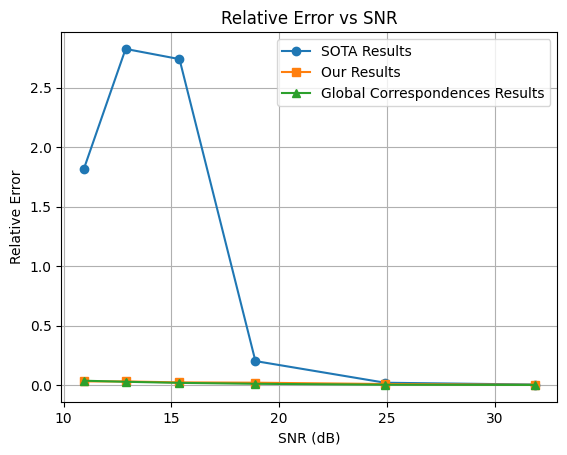

In [376]:
import numpy as np
import matplotlib.pyplot as plt



# Convert to numpy arrays
list1 = np.array(SOTA_results)
list2 = np.array(our_results)
list3 = np.array(global_correspondences_results)

# Plot each list
plt.plot(list1[:, 0], list1[:, 1], marker='o', label='SOTA Results')
plt.plot(list2[:, 0], list2[:, 1], marker='s', label='Our Results')
plt.plot(list3[:, 0], list3[:, 1], marker='^', label='Global Correspondences Results')

# Labels and title
plt.xlabel('SNR (dB)')
plt.ylabel('Relative Error')
plt.title('Relative Error vs SNR')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()